# M7 — PCA Reconstruction Baseline

This notebook evaluates PCA reconstruction as a baseline anomaly detector for DeepSeti.

## Research rule

PCA is trained **only on normal real radio observations from the training split**.

Synthetic technosignature injections are used only for validation/testing and are never used for training.

## Goal

Test whether reconstruction error is higher for synthetic technosignature-like anomalies than for clean radio spectrogram frames.

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

from deepseti.injection.dataset import load_split_frame_pool
from deepseti.preprocessing.frames import normalize_frames
from deepseti.models.pca import PCAAnomalyDetector

/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
raw_train, train_metadata = load_split_frame_pool(
    manifest_path="../configs/data/observations.csv",
    raw_root="../data/raw",
    split="train",
    f_start=2200,
    f_stop=2300,
)

train_frames = normalize_frames(raw_train)

print("Training frames:", train_frames.shape)
print("Metadata rows:", len(train_metadata))
print(
    "Number of observations:",
    len({m["observation_id"] for m in train_metadata}),
)
print("All finite:", np.isfinite(train_frames).all())

Training frames: (816, 16, 4096)
Metadata rows: 816
Number of observations: 6
All finite: True


In [3]:
pca_model = PCAAnomalyDetector(
    n_components=64,
    random_state=42,
)

pca_model.fit(train_frames)

explained_variance = (
    pca_model.model.explained_variance_ratio_.sum()
)

print("PCA components:", pca_model.n_components)
print("Explained variance:", explained_variance)

PCA components: 64
Explained variance: 0.9764933


In [4]:
validation_clean = np.load(
    "../data/synthetic/validation/clean_frames.npy"
)

validation_injected = np.load(
    "../data/synthetic/validation/injected_frames.npy"
)

with open(
    "../data/synthetic/validation/metadata.json"
) as f:
    validation_metadata = json.load(f)

print("Clean frames:", validation_clean.shape)
print("Injected frames:", validation_injected.shape)
print("Metadata rows:", len(validation_metadata))

Clean frames: (700, 16, 4096)
Injected frames: (700, 16, 4096)
Metadata rows: 700


In [5]:
clean_scores = pca_model.score(validation_clean)
injected_scores = pca_model.score(validation_injected)

labels = np.concatenate([
    np.zeros(len(clean_scores)),
    np.ones(len(injected_scores)),
])

scores = np.concatenate([
    clean_scores,
    injected_scores,
])

validation_auroc = roc_auc_score(
    labels,
    scores,
)

validation_auprc = average_precision_score(
    labels,
    scores,
)

print("Mean clean score:", clean_scores.mean())
print("Mean injected score:", injected_scores.mean())
print("Validation AUROC:", validation_auroc)
print("Validation AUPRC:", validation_auprc)

Mean clean score: 0.5999226
Mean injected score: 0.64031196
Validation AUROC: 0.5601571428571428
Validation AUPRC: 0.5446772283909762


In [6]:
snr_results = []

for snr in [0.5, 1.0, 2.0, 5.0, 10.0]:

    indices = [
        i
        for i, item in enumerate(validation_metadata)
        if item["robust_snr"] == snr
    ]

    clean_snr_scores = clean_scores[indices]
    injected_snr_scores = injected_scores[indices]

    snr_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    snr_scores = np.concatenate([
        clean_snr_scores,
        injected_snr_scores,
    ])

    auroc = roc_auc_score(
        snr_labels,
        snr_scores,
    )

    mean_paired_increase = (
        injected_snr_scores - clean_snr_scores
    ).mean()

    snr_results.append({
        "robust_snr": snr,
        "auroc": auroc,
        "mean_paired_increase": mean_paired_increase,
    })

    print(
        f"SNR {snr:>4}: "
        f"AUROC={auroc:.3f}  "
        f"mean paired increase={mean_paired_increase:.4f}"
    )

SNR  0.5: AUROC=0.506  mean paired increase=0.0006
SNR  1.0: AUROC=0.517  mean paired increase=0.0019
SNR  2.0: AUROC=0.533  mean paired increase=0.0074
SNR  5.0: AUROC=0.591  mean paired increase=0.0430
SNR 10.0: AUROC=0.647  mean paired increase=0.1492


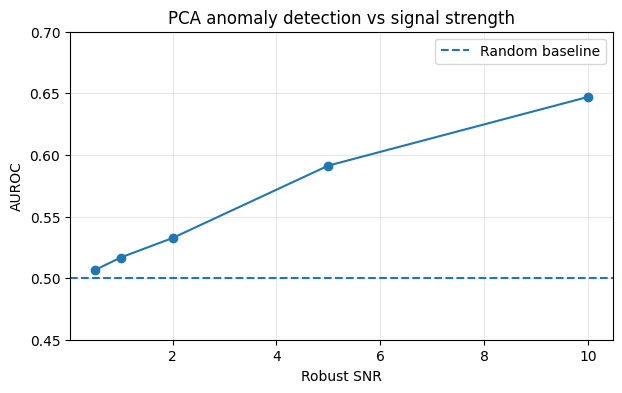

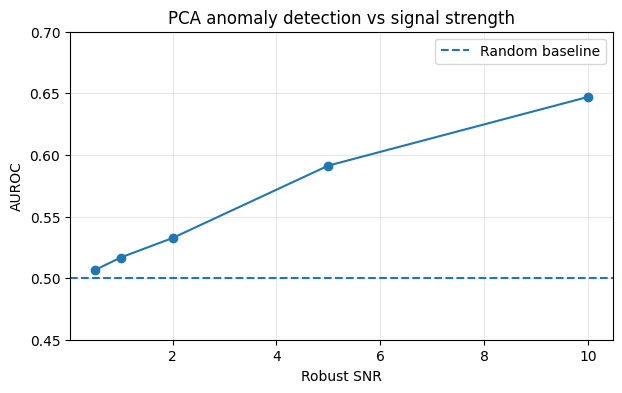

In [8]:
%matplotlib inline
snr_values = [
    result["robust_snr"]
    for result in snr_results
]

snr_aurocs = [
    result["auroc"]
    for result in snr_results
]

plt.figure(figsize=(7, 4))

plt.plot(
    snr_values,
    snr_aurocs,
    marker="o",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline",
)

plt.xlabel("Robust SNR")
plt.ylabel("AUROC")
plt.title("PCA anomaly detection vs signal strength")

plt.ylim(0.45, 0.70)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [9]:
morphology_results = []

morphologies = sorted({
    item["morphology"]
    for item in validation_metadata
})

for morphology in morphologies:

    indices = [
        i
        for i, item in enumerate(validation_metadata)
        if item["morphology"] == morphology
    ]

    morphology_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    morphology_scores = np.concatenate([
        clean_scores[indices],
        injected_scores[indices],
    ])

    auroc = roc_auc_score(
        morphology_labels,
        morphology_scores,
    )

    mean_paired_increase = (
        injected_scores[indices]
        - clean_scores[indices]
    ).mean()

    morphology_results.append({
        "morphology": morphology,
        "auroc": auroc,
        "mean_paired_increase": mean_paired_increase,
    })

    print(
        f"{morphology:22s} "
        f"AUROC={auroc:.3f}  "
        f"mean paired increase={mean_paired_increase:.4f}"
    )

burst                  AUROC=0.599  mean paired increase=0.0917
intermittent           AUROC=0.521  mean paired increase=0.0058
linear_drift           AUROC=0.538  mean paired increase=0.0109
multiple_carriers      AUROC=0.593  mean paired increase=0.0372
nonlinear_drift        AUROC=0.536  mean paired increase=0.0110
stationary_narrowband  AUROC=0.558  mean paired increase=0.0224


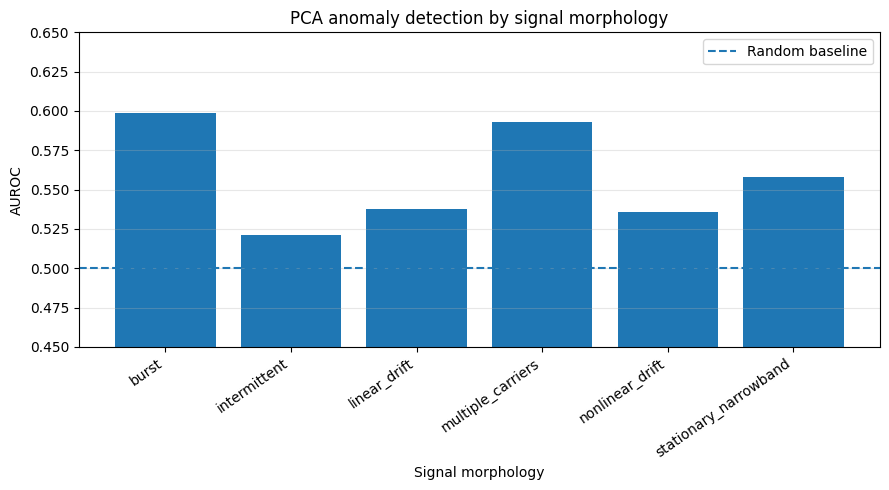

In [10]:
morphology_names = [
    result["morphology"]
    for result in morphology_results
]

morphology_aurocs = [
    result["auroc"]
    for result in morphology_results
]

plt.figure(figsize=(9, 5))

plt.bar(
    morphology_names,
    morphology_aurocs,
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline",
)

plt.ylabel("AUROC")
plt.xlabel("Signal morphology")
plt.title("PCA anomaly detection by signal morphology")

plt.ylim(0.45, 0.65)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
component_options = [8, 16, 32, 64, 128]

component_results = []

for n_components in component_options:

    print(f"Fitting PCA with {n_components} components...")

    model = PCAAnomalyDetector(
        n_components=n_components,
        random_state=42,
    )

    model.fit(train_frames)

    clean_component_scores = model.score(
        validation_clean
    )

    injected_component_scores = model.score(
        validation_injected
    )

    component_labels = np.concatenate([
        np.zeros(len(clean_component_scores)),
        np.ones(len(injected_component_scores)),
    ])

    component_scores = np.concatenate([
        clean_component_scores,
        injected_component_scores,
    ])

    auroc = roc_auc_score(
        component_labels,
        component_scores,
    )

    auprc = average_precision_score(
        component_labels,
        component_scores,
    )

    explained_variance = (
        model.model.explained_variance_ratio_.sum()
    )

    component_results.append({
        "n_components": n_components,
        "auroc": auroc,
        "auprc": auprc,
        "explained_variance": explained_variance,
    })

    print(
        f"components={n_components:3d} | "
        f"variance={explained_variance:.4f} | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

Fitting PCA with 8 components...
components=  8 | variance=0.9559 | AUROC=0.5558 | AUPRC=0.5424
Fitting PCA with 16 components...
components= 16 | variance=0.9645 | AUROC=0.5553 | AUPRC=0.5418
Fitting PCA with 32 components...
components= 32 | variance=0.9716 | AUROC=0.5564 | AUPRC=0.5421
Fitting PCA with 64 components...
components= 64 | variance=0.9765 | AUROC=0.5602 | AUPRC=0.5447
Fitting PCA with 128 components...
components=128 | variance=0.9823 | AUROC=0.5603 | AUPRC=0.5449


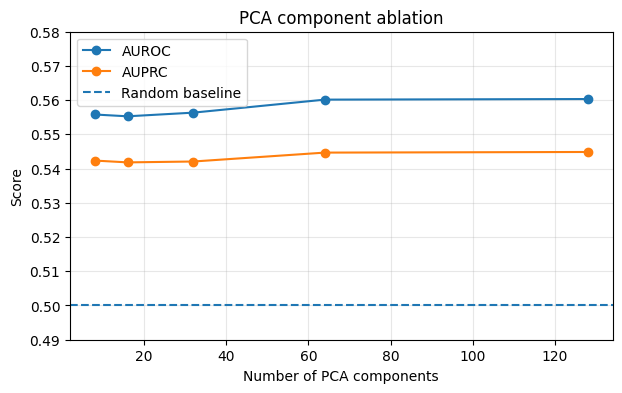

In [12]:
component_counts = [
    result["n_components"]
    for result in component_results
]

component_aurocs = [
    result["auroc"]
    for result in component_results
]

component_auprcs = [
    result["auprc"]
    for result in component_results
]

plt.figure(figsize=(7, 4))

plt.plot(
    component_counts,
    component_aurocs,
    marker="o",
    label="AUROC",
)

plt.plot(
    component_counts,
    component_auprcs,
    marker="o",
    label="AUPRC",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline",
)

plt.xlabel("Number of PCA components")
plt.ylabel("Score")
plt.title("PCA component ablation")

plt.ylim(0.49, 0.58)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [13]:
def top_fraction_score(
    model,
    frames,
    fraction=0.001,
    batch_size=32,
):
    scores = []

    for start in range(0, len(frames), batch_size):
        batch = frames[start:start + batch_size]

        reconstructed = model.reconstruct(batch)

        squared_error = (
            batch - reconstructed
        ) ** 2

        flattened_error = squared_error.reshape(
            len(batch),
            -1,
        )

        k = max(
            1,
            int(flattened_error.shape[1] * fraction),
        )

        top_errors = np.partition(
            flattened_error,
            -k,
            axis=1,
        )[:, -k:]

        scores.extend(
            top_errors.mean(axis=1)
        )

    return np.asarray(scores)


clean_top_scores = top_fraction_score(
    pca_model,
    validation_clean,
)

injected_top_scores = top_fraction_score(
    pca_model,
    validation_injected,
)

top_scores = np.concatenate([
    clean_top_scores,
    injected_top_scores,
])

top_auroc = roc_auc_score(
    labels,
    top_scores,
)

top_auprc = average_precision_score(
    labels,
    top_scores,
)

print("Whole-frame mean AUROC:", validation_auroc)
print("Top 0.1% AUROC:", top_auroc)

print("Whole-frame mean AUPRC:", validation_auprc)
print("Top 0.1% AUPRC:", top_auprc)

Whole-frame mean AUROC: 0.5601571428571428
Top 0.1% AUROC: 0.6444285714285715
Whole-frame mean AUPRC: 0.5446772283909762
Top 0.1% AUPRC: 0.590329657662618


In [14]:
fraction_options = [
    0.00025,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
]

fraction_results = []

for fraction in fraction_options:

    clean_fraction_scores = top_fraction_score(
        pca_model,
        validation_clean,
        fraction=fraction,
    )

    injected_fraction_scores = top_fraction_score(
        pca_model,
        validation_injected,
        fraction=fraction,
    )

    combined_scores = np.concatenate([
        clean_fraction_scores,
        injected_fraction_scores,
    ])

    auroc = roc_auc_score(
        labels,
        combined_scores,
    )

    auprc = average_precision_score(
        labels,
        combined_scores,
    )

    pixels = int(
        validation_clean.shape[1]
        * validation_clean.shape[2]
        * fraction
    )

    fraction_results.append({
        "fraction": fraction,
        "pixels": pixels,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"fraction={fraction:.5f} "
        f"(~{pixels:4d} pixels) | "
        f"AUROC={auroc:.4f} | "
        f"AUPRC={auprc:.4f}"
    )

fraction=0.00025 (~  16 pixels) | AUROC=0.6395 | AUPRC=0.5848
fraction=0.00050 (~  32 pixels) | AUROC=0.6423 | AUPRC=0.5869
fraction=0.00100 (~  65 pixels) | AUROC=0.6444 | AUPRC=0.5903
fraction=0.00200 (~ 131 pixels) | AUROC=0.6462 | AUPRC=0.5944
fraction=0.00500 (~ 327 pixels) | AUROC=0.6386 | AUPRC=0.5935
fraction=0.01000 (~ 655 pixels) | AUROC=0.6284 | AUPRC=0.5897


In [15]:
best_fraction_result = max(
    fraction_results,
    key=lambda result: result["auroc"],
)

best_fraction = best_fraction_result["fraction"]

print("Selected PCA components:", 64)
print("Selected top-error fraction:", best_fraction)
print("Approx. pixels used:", best_fraction_result["pixels"])
print("Validation AUROC:", best_fraction_result["auroc"])
print("Validation AUPRC:", best_fraction_result["auprc"])

Selected PCA components: 64
Selected top-error fraction: 0.002
Approx. pixels used: 131
Validation AUROC: 0.6461673469387755
Validation AUPRC: 0.5944344738901635


In [16]:
clean_best_scores = top_fraction_score(
    pca_model,
    validation_clean,
    fraction=best_fraction,
)

injected_best_scores = top_fraction_score(
    pca_model,
    validation_injected,
    fraction=best_fraction,
)

best_snr_results = []

for snr in [0.5, 1.0, 2.0, 5.0, 10.0]:

    indices = [
        i
        for i, item in enumerate(validation_metadata)
        if item["robust_snr"] == snr
    ]

    clean_snr_scores = clean_best_scores[indices]
    injected_snr_scores = injected_best_scores[indices]

    snr_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    snr_scores = np.concatenate([
        clean_snr_scores,
        injected_snr_scores,
    ])

    auroc = roc_auc_score(
        snr_labels,
        snr_scores,
    )

    auprc = average_precision_score(
        snr_labels,
        snr_scores,
    )

    best_snr_results.append({
        "robust_snr": snr,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"SNR {snr:>4}: "
        f"AUROC={auroc:.3f}  "
        f"AUPRC={auprc:.3f}"
    )

SNR  0.5: AUROC=0.505  AUPRC=0.512
SNR  1.0: AUROC=0.529  AUPRC=0.514
SNR  2.0: AUROC=0.597  AUPRC=0.552
SNR  5.0: AUROC=0.747  AUPRC=0.648
SNR 10.0: AUROC=0.823  AUPRC=0.704


In [17]:
best_morphology_results = []

for morphology in morphologies:

    indices = [
        i
        for i, item in enumerate(validation_metadata)
        if item["morphology"] == morphology
    ]

    morphology_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    morphology_scores = np.concatenate([
        clean_best_scores[indices],
        injected_best_scores[indices],
    ])

    auroc = roc_auc_score(
        morphology_labels,
        morphology_scores,
    )

    auprc = average_precision_score(
        morphology_labels,
        morphology_scores,
    )

    best_morphology_results.append({
        "morphology": morphology,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"{morphology:22s} "
        f"AUROC={auroc:.3f}  "
        f"AUPRC={auprc:.3f}"
    )

burst                  AUROC=0.687  AUPRC=0.638
intermittent           AUROC=0.573  AUPRC=0.547
linear_drift           AUROC=0.626  AUPRC=0.570
multiple_carriers      AUROC=0.678  AUPRC=0.634
nonlinear_drift        AUROC=0.632  AUPRC=0.576
stationary_narrowband  AUROC=0.650  AUPRC=0.615


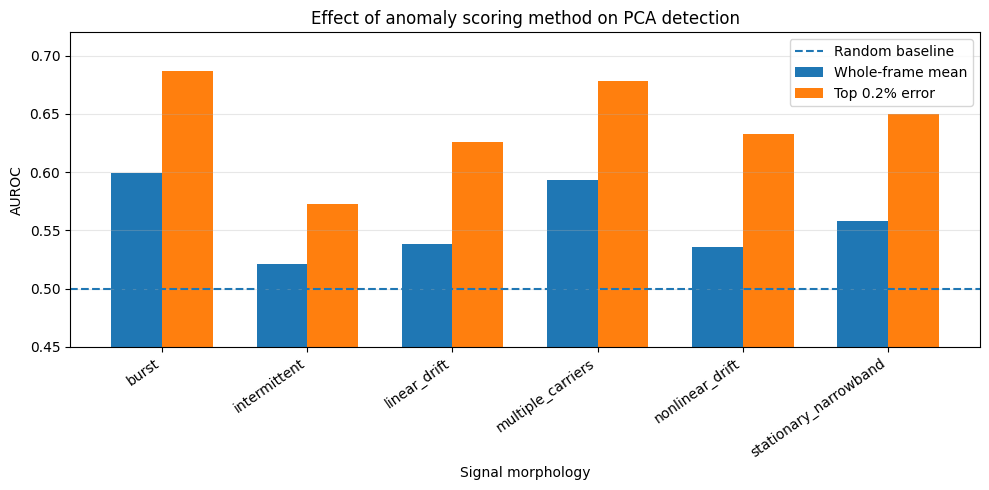

In [18]:
old_auroc_by_morphology = {
    result["morphology"]: result["auroc"]
    for result in morphology_results
}

new_auroc_by_morphology = {
    result["morphology"]: result["auroc"]
    for result in best_morphology_results
}

comparison_morphologies = list(
    old_auroc_by_morphology.keys()
)

old_values = [
    old_auroc_by_morphology[m]
    for m in comparison_morphologies
]

new_values = [
    new_auroc_by_morphology[m]
    for m in comparison_morphologies
]

x = np.arange(len(comparison_morphologies))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    old_values,
    width,
    label="Whole-frame mean",
)

plt.bar(
    x + width / 2,
    new_values,
    width,
    label="Top 0.2% error",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline",
)

plt.xticks(
    x,
    comparison_morphologies,
    rotation=35,
    ha="right",
)

plt.ylabel("AUROC")
plt.xlabel("Signal morphology")
plt.title("Effect of anomaly scoring method on PCA detection")

plt.ylim(0.45, 0.72)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
test_clean = np.load(
    "../data/synthetic/test/clean_frames.npy"
)

test_injected = np.load(
    "../data/synthetic/test/injected_frames.npy"
)

with open(
    "../data/synthetic/test/metadata.json"
) as f:
    test_metadata = json.load(f)


test_clean_scores = top_fraction_score(
    pca_model,
    test_clean,
    fraction=0.002,
)

test_injected_scores = top_fraction_score(
    pca_model,
    test_injected,
    fraction=0.002,
)

test_labels = np.concatenate([
    np.zeros(len(test_clean_scores)),
    np.ones(len(test_injected_scores)),
])

test_scores = np.concatenate([
    test_clean_scores,
    test_injected_scores,
])

test_auroc = roc_auc_score(
    test_labels,
    test_scores,
)

test_auprc = average_precision_score(
    test_labels,
    test_scores,
)

print("FINAL PCA TEST RESULTS")
print("AUROC:", test_auroc)
print("AUPRC:", test_auprc)

FINAL PCA TEST RESULTS
AUROC: 0.6768551020408163
AUPRC: 0.6435536752089339


In [20]:
test_snr_results = []

for snr in [0.5, 1.0, 2.0, 5.0, 10.0]:

    indices = [
        i
        for i, item in enumerate(test_metadata)
        if item["robust_snr"] == snr
    ]

    snr_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    snr_scores = np.concatenate([
        test_clean_scores[indices],
        test_injected_scores[indices],
    ])

    auroc = roc_auc_score(
        snr_labels,
        snr_scores,
    )

    auprc = average_precision_score(
        snr_labels,
        snr_scores,
    )

    test_snr_results.append({
        "robust_snr": snr,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"SNR {snr:>4}: "
        f"AUROC={auroc:.3f}  "
        f"AUPRC={auprc:.3f}"
    )

SNR  0.5: AUROC=0.506  AUPRC=0.510
SNR  1.0: AUROC=0.545  AUPRC=0.528
SNR  2.0: AUROC=0.627  AUPRC=0.574
SNR  5.0: AUROC=0.793  AUPRC=0.717
SNR 10.0: AUROC=0.900  AUPRC=0.823


In [21]:
test_morphology_results = []

test_morphologies = sorted({
    item["morphology"]
    for item in test_metadata
})

for morphology in test_morphologies:

    indices = [
        i
        for i, item in enumerate(test_metadata)
        if item["morphology"] == morphology
    ]

    morphology_labels = np.concatenate([
        np.zeros(len(indices)),
        np.ones(len(indices)),
    ])

    morphology_scores = np.concatenate([
        test_clean_scores[indices],
        test_injected_scores[indices],
    ])

    auroc = roc_auc_score(
        morphology_labels,
        morphology_scores,
    )

    auprc = average_precision_score(
        morphology_labels,
        morphology_scores,
    )

    test_morphology_results.append({
        "morphology": morphology,
        "auroc": auroc,
        "auprc": auprc,
    })

    print(
        f"{morphology:22s} "
        f"AUROC={auroc:.3f}  "
        f"AUPRC={auprc:.3f}"
    )

burst                  AUROC=0.723  AUPRC=0.722
intermittent           AUROC=0.581  AUPRC=0.570
linear_drift           AUROC=0.661  AUPRC=0.620
multiple_carriers      AUROC=0.699  AUPRC=0.688
nonlinear_drift        AUROC=0.656  AUPRC=0.620
stationary_narrowband  AUROC=0.697  AUPRC=0.666


In [22]:
from pathlib import Path

pca_results = {
    "model": "PCA reconstruction baseline",
    "n_components": 64,
    "anomaly_score": "mean of top 0.2% squared reconstruction errors",
    "top_error_fraction": 0.002,
    "training_frames": len(train_frames),
    "training_observations": 6,

    "validation": {
        "auroc": float(best_fraction_result["auroc"]),
        "auprc": float(best_fraction_result["auprc"]),
    },

    "test": {
        "auroc": float(test_auroc),
        "auprc": float(test_auprc),
    },

    "test_by_snr": test_snr_results,
    "test_by_morphology": test_morphology_results,
}

output_path = Path("../results/pca_baseline.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with output_path.open("w") as f:
    json.dump(
        pca_results,
        f,
        indent=2,
    )

print("Saved:", output_path)

Saved: ../results/pca_baseline.json
